Epoch 1/500, Train Loss: 0.896533, Val Loss: 1.548287
Epoch 50/500, Train Loss: 0.364533, Val Loss: 2.516159
Early stopping at epoch 51, best val_loss=1.548287


/Users/ajay.amrite/Documents/AI Course/Capstone/Black-Box functions/models/SurrogateNN.py:117: UserWarning: std(): degrees of freedom is <= 0. Correction should be strictly less than the reduction factor (input numel divided by output numel). (Triggered internally at /Users/runner/work/_temp/anaconda/conda-bld/pytorch_1711403226260/work/aten/src/ATen/native/ReduceOps.cpp:1760.)
  "std": param.data.std().item()


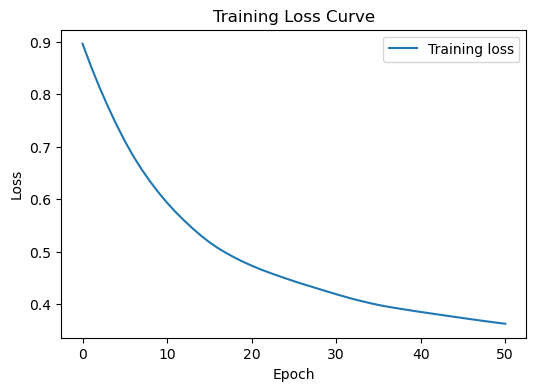

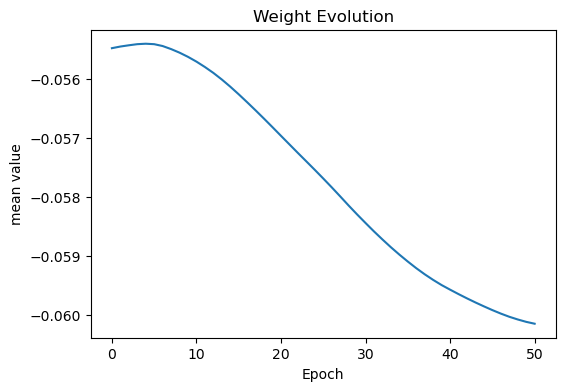

Using 2 dimensions.
Points before downsampling: 10000
Points after downsampling: 10000
Final grid shape: (10000, 2)
Filtered 185 candidates near decision boundary (|margin| < 0.2)
Excluded 9815 candidates from consideration
Final grid shape: (185, 2)
Total number of points to evaluate: 9
{'method': 'PI', 'xi': 0.01, 'kappa': None, 'x': array([0.51496772, 0.14166177]), 'score': 8.874919266149653e-20, 'dim': 2, 'predicted_y': 0.21190311}
{'method': 'PI', 'xi': 0.1, 'kappa': None, 'x': array([0.51496772, 0.14166177]), 'score': 3.3245283577604913e-22, 'dim': 2, 'predicted_y': 0.21190311}
{'method': 'PI', 'xi': 0.3, 'kappa': None, 'x': array([0.51496772, 0.14166177]), 'score': 3.8804959270162416e-28, 'dim': 2, 'predicted_y': 0.21190311}
{'method': 'EI', 'xi': 0.01, 'kappa': None, 'x': array([0.51496772, 0.14166177]), 'score': 1.4585949449776776e-21, 'dim': 2, 'predicted_y': 0.21190311}
{'method': 'EI', 'xi': 0.1, 'kappa': None, 'x': array([0.51496772, 0.14166177]), 'score': 5.14104951266568

In [1]:
# flows/function1_flow.py

import sys, os
try:
    # Works when running as a normal Python script
    project_root = os.path.abspath(os.path.join(os.path.dirname(__file__), '..'))
except NameError:
    # Fallback for Jupyter/IPython where __file__ is not defined
    project_root = os.path.abspath(os.path.join(os.getcwd(), '..'))
sys.path.append(project_root)

from data.BaseDataHandler import BaseDataHandler
from optimisation.BayesOptUtils import BayesOptUtils
from plotting.PlotUtils import PlotUtils
from Function2DataHandler import Function2DataHandler  # same folder
from models.SurrogateNN import SurrogateTrainer

# --- Data ---
dh = Function2DataHandler()
dh.add_weekly_updates()
df_sorted = dh.build_dataframe()
X, y = dh.inputs, dh.outputs

# --- Utilities ---
utils = BayesOptUtils()
plotter = PlotUtils()
trainer = SurrogateTrainer(input_dim=X.shape[1], lr=1e-3, epochs=500)

# --- Hyperparameters supplied here ---
xi_values = [0.01, 0.1, 0.3]
kappa_values = [1.0, 2.0, 3.0]
grid_sizes = [100, 200, 400]
methods = ['PI', 'EI', 'UCB']
apply_scaling = True
filter_mode = 'gp'

# --- Run flow ---
results = utils.run_flow(
    trainer, X, y,
    xi_values=xi_values,
    kappa_values=kappa_values,
    grid_sizes=grid_sizes,
    methods=methods,
    apply_scaling=apply_scaling,
    filter_mode=filter_mode
)



=== Results for grid_size=100 ===


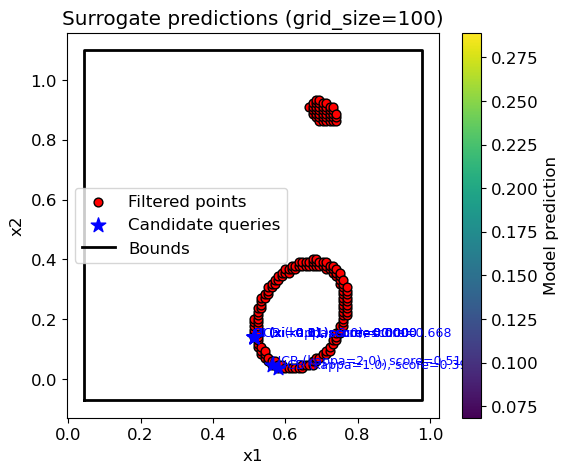

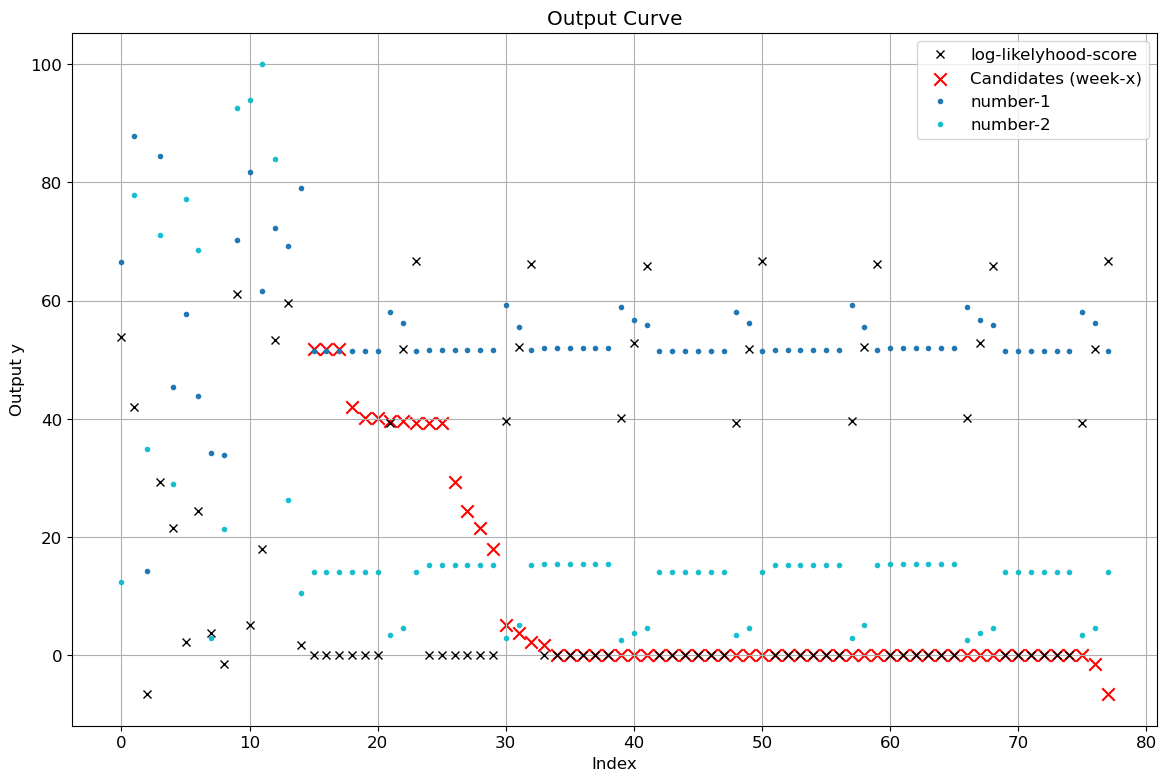

Best candidate: {'method': 'UCB', 'xi': None, 'kappa': 3.0, 'x': array([0.51496772, 0.14166177]), 'score': 0.6675010928178212, 'dim': 2, 'predicted_y': 0.21190311}

=== Results for grid_size=200 ===


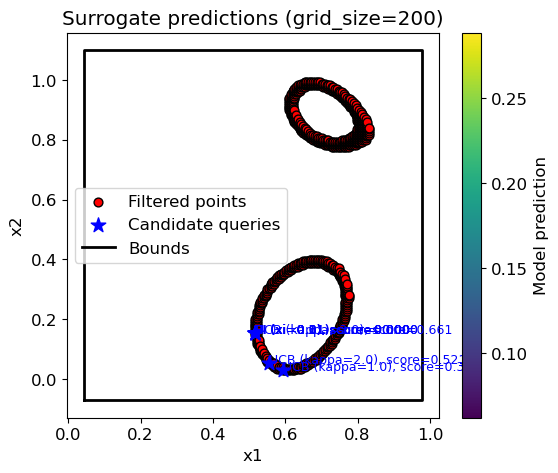

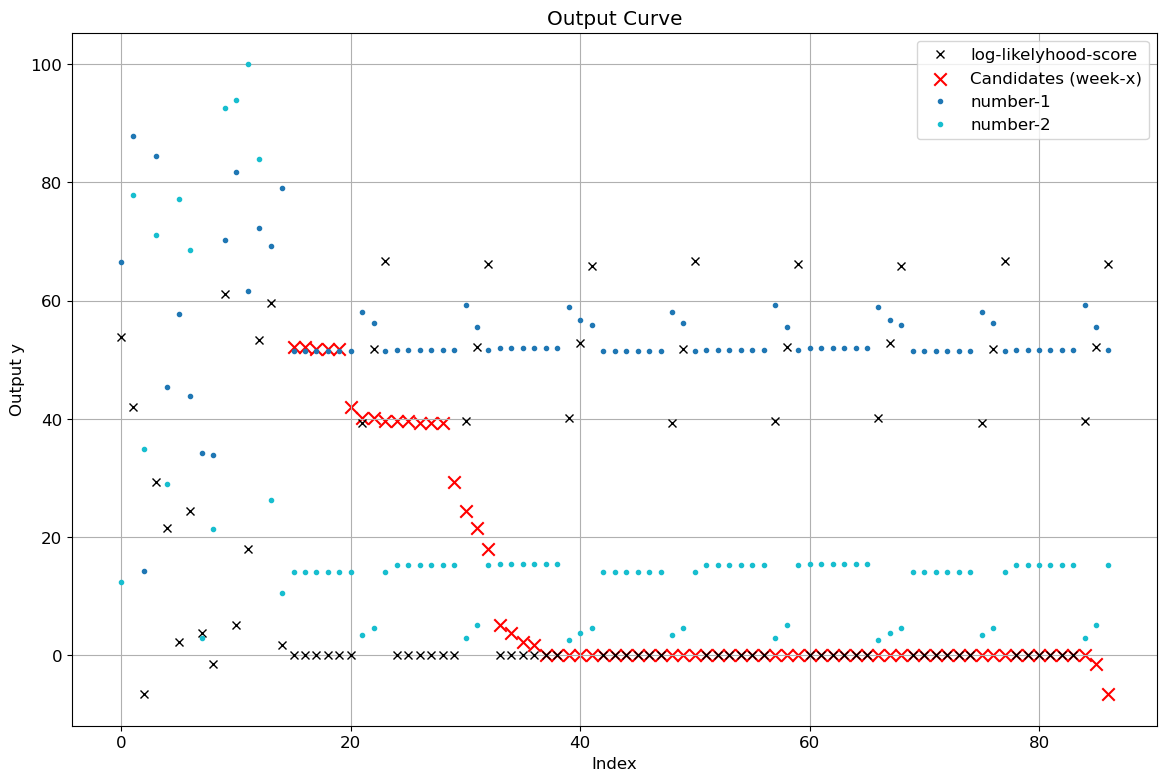

Best candidate: {'method': 'UCB', 'xi': None, 'kappa': 3.0, 'x': array([0.51729346, 0.15236348]), 'score': 0.6613286702812742, 'dim': 2, 'predicted_y': 0.20773992}

=== Results for grid_size=400 ===


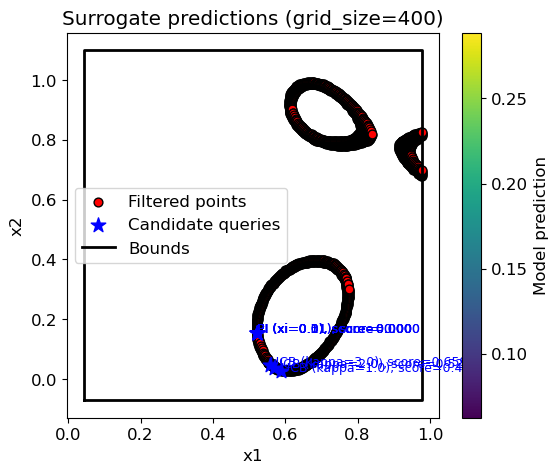

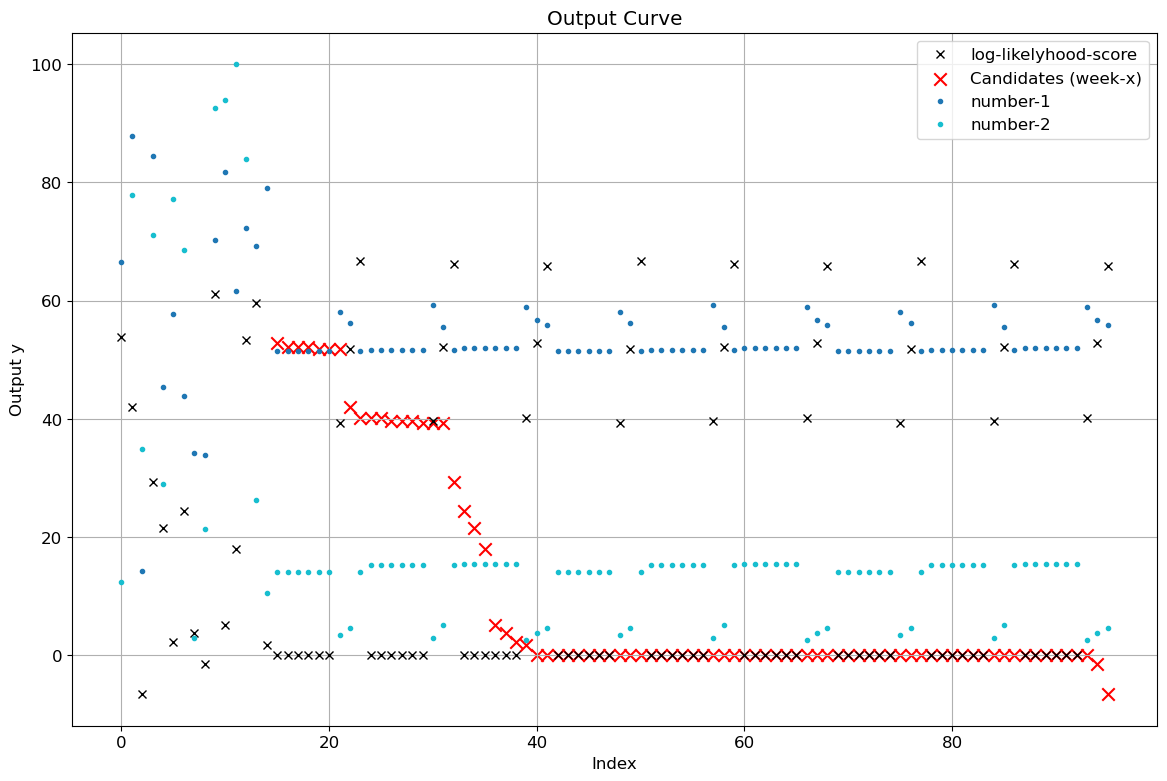

Best candidate: {'method': 'UCB', 'xi': None, 'kappa': 3.0, 'x': array([0.5582886 , 0.04612151]), 'score': 0.6586243407611705, 'dim': 2, 'predicted_y': 0.26041615}


In [4]:
import matplotlib as mpl
mpl.rcParams['figure.figsize'] = (14, 9)
mpl.rcParams['figure.dpi'] = 100
mpl.rcParams['font.size'] = 12

# --- Loop over results and plot ---
for grid_size, (X_grid_filtered, mean, bounds, best, query_results, acq_maps) in results.items():
    print(f"\n=== Results for grid_size={grid_size} ===")

    # Extract candidates and labels
    candidates, labels = plotter.extract_candidates_and_labels(query_results, include_score=True)

    # Surrogate predictions plot
    plotter.plot_surrogate_generic(
        X_grid_filtered, mean,
        X_filtered=X_grid_filtered,
        bounds=bounds,
        candidates=candidates,
        candidate_labels=labels,
        title=f"Surrogate predictions (grid_size={grid_size})"
    )

    # Append candidates to BaseDataHandler and rebuild DataFrame
    cand_array, y_pred_array = dh.extract_candidate_arrays(query_results)
    dh.add_candidates(cand_array, y_pred_array)  # updates inputs/outputs/source_labels
    df_sorted = dh.build_dataframe()             # rebuild from updated arrays

    # Re-plot updated DataFrame
    plotter.plot_output_points(
        df_sorted,
        scale_factor=100.0,
        yield_scale_factor=100.0,
        source_marker='week-x',          # highlight all rows with source == 'week-x'
        source_color='red',
        source_marker_style='x'
    )
    # Print best candidate info
    print("Best candidate:", best)